Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath(".."))

from sklearn.preprocessing import StandardScaler
from src.pca_analysis import run_pca


Load clr data

In [3]:
df = pd.read_csv("../data/processed/synthetic_geochemistry_clean.csv")
elements = [c for c in df.columns if c not in ["cluster_true"]]

from src.compositional_transforms import clr
df_clr = clr(df[elements])
df_clr.head(10)

,Br,Cl,F,SO4,Ca,Mg,Sr,Cu,Co,Pb,Zn,Li,Na,K,Mn,Fe,Ba
0,0.746251,0.315967,-0.725338,1.031902,0.322700,0.614582,0.798161,-1.001871,-1.241130,-0.897711,-1.715558,0.482986,0.800385,0.080730,0.569394,-0.131824,-0.049627
1,0.729605,0.660838,-0.991739,0.888241,0.227267,0.054199,0.054580,-1.275910,-0.644361,-0.378698,-1.059244,0.209740,1.069177,0.445892,0.139806,-0.091344,-0.038048
2,0.871193,1.011035,-0.627001,0.926490,0.385496,-0.278802,-0.442086,-1.435748,-1.106555,-0.182974,-1.053325,0.498767,1.727061,0.812838,0.019348,-0.379677,-0.746062
3,1.090503,0.825440,-0.612017,1.420517,0.507270,0.079267,-0.975566,-0.768535,-1.127371,-0.709225,-0.263633,-0.129010,0.981496,-0.101476,-0.103580,0.487791,-0.601873
4,0.449769,0.635069,-0.832540,0.938980,0.272746,0.041319,-1.058140,-1.632335,-0.287189,-0.956847,-0.733949,0.783759,1.278069,0.727864,0.498698,0.236396,-0.361669
5,0.494237,0.734823,-0.349069,0.911110,0.312247,-0.084045,-0.904176,-0.455039,-0.375924,-0.594073,-1.446301,0.812440,0.850622,0.191283,0.174734,0.577595,-0.850466
6,1.190138,1.169518,-1.173684,0.178524,-0.162743,0.576285,-0.007984,-1.501796,-1.461380,-0.983592,-0.747133,0.571255,0.824497,0.656082,0.705484,0.703689,-0.537159
7,0.919244,0.475641,-1.261127,1.285397,-0.085471,0.785453,0.166632,-0.832373,-0.555837,-0.978169,-1.506652,0.556934,1.436865,-0.109775,-0.915043,0.545078,0.073202
8,0.413773,0.920402,-1.432053,1.224305,-0.540000,0.254607,-0.889033,-1.229885,-0.573879,-1.139003,-0.465361,1.106038,0.696690,0.477334,0.073137,0.730444,0.372485
9,0.613614,0.415713,-0.654597,1.778217,1.146336,0.883108,0.144109,-1.062135,-1.562715,-0.578045,-1.291860,0.196465,0.772026,-0.124441,-0.266437,0.161824,-0.571184


Principal Component Analysis (PCA)

In [4]:
pca, scores, loadings = run_pca(df_clr, n_components=4)

scores_df = pd.DataFrame(scores, columns=["PC1","PC2","PC3","PC4"])
scores_df["cluster_true"] = df["cluster_true"]
loadings

,PC1,PC2,PC3,PC4
Br,-0.389443,0.033971,-0.045693,-0.079821
Cl,-0.364767,0.014640,-0.165891,0.047419
F,-0.112274,-0.008371,-0.064894,0.043225
SO4,-0.357663,-0.059974,-0.101397,-0.478999
Ca,-0.032219,0.716470,0.627333,0.091140
Mg,0.015302,-0.678084,0.670665,-0.021652
Sr,0.034944,-0.094481,-0.147684,0.740965
Cu,0.388401,0.011083,-0.113015,-0.171597
Co,0.313028,0.006649,0.040112,-0.116272
Pb,0.389492,0.020273,-0.092759,-0.190065


Scree plot

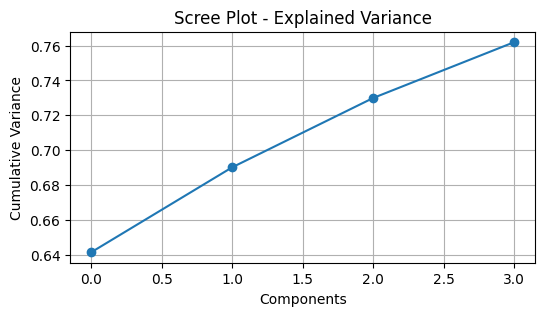

In [8]:
plt.figure(figsize=(6,3))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.title("Scree Plot - Explained Variance")
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.show()

Loadings Plot

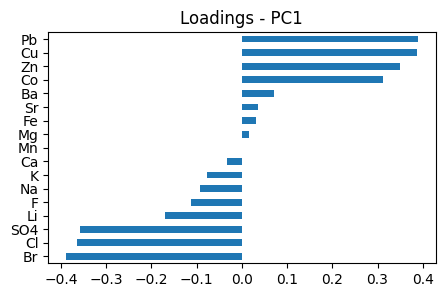

In [7]:
plt.figure(figsize=(5,3))
loadings["PC1"].sort_values().plot(kind="barh")
plt.title("Loadings - PC1")
plt.show()

Biplot PC1 vs PC2

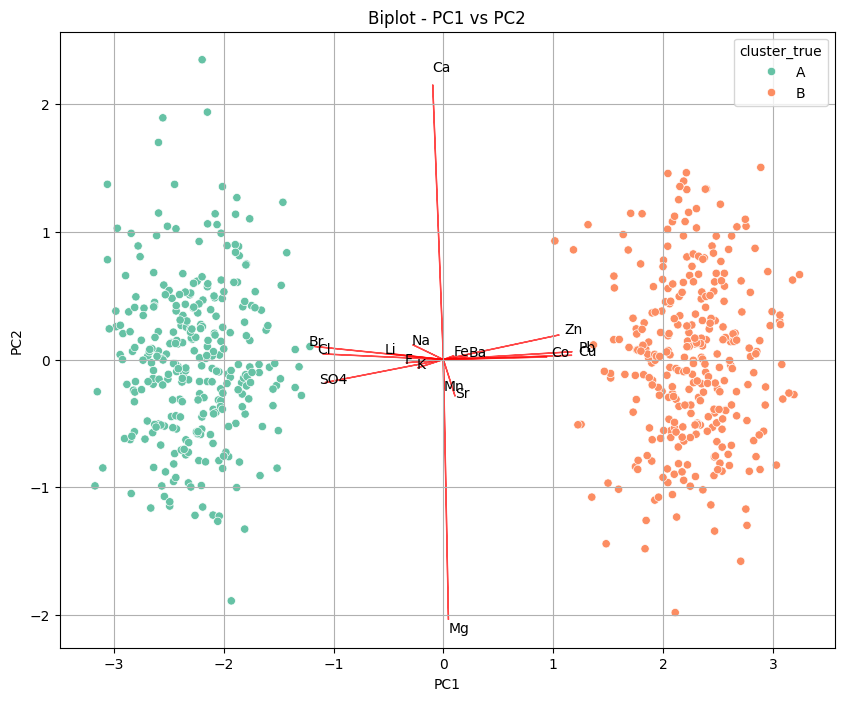

In [ ]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x=scores_df["PC1"], 
    y=scores_df["PC2"], 
    hue=scores_df["cluster_true"],
    palette="Set2"
)

for i, element in enumerate(elements):
    x_val = loadings["PC1"].iloc[i] * 3
    y_val = loadings["PC2"].iloc[i] * 3
    
    plt.arrow(0, 0, x_val, y_val, color="red", alpha=0.7)
    plt.text(x_val * 1.05, y_val * 1.05, element)

plt.title("Biplot - PC1 vs PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()